<a href="https://colab.research.google.com/github/ChinthakindhiNishitha/DeepLearining/blob/main/Week5(L2_Reguralarization).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import h5py
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

train_path = "/content/drive/MyDrive/Signs_Data_Training.h5"
test_path = "/content/drive/MyDrive/Signs_Data_Testing.h5"

with h5py.File(train_path, "r") as train_dataset:
    X_train = np.array(train_dataset["train_set_x"])
    Y_train = np.array(train_dataset["train_set_y"])

with h5py.File(test_path, "r") as test_dataset:
    X_test = np.array(test_dataset["test_set_x"])
    Y_test = np.array(test_dataset["test_set_y"])

# Normalize
X_train = X_train/255.0
X_test = X_test/255.0

# Flatten for MLP
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# One-hot encoding
Y_train = tf.keras.utils.to_categorical(Y_train,6)
Y_test = tf.keras.utils.to_categorical(Y_test,6)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.2037 - loss: 2.8019 - val_accuracy: 0.2222 - val_loss: 1.8148
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.2789 - loss: 1.7474 - val_accuracy: 0.3009 - val_loss: 1.7133
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3345 - loss: 1.6508 - val_accuracy: 0.3287 - val_loss: 1.6079
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4190 - loss: 1.5103 - val_accuracy: 0.3565 - val_loss: 1.5695
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.4444 - loss: 1.4793 - val_accuracy: 0.3935 - val_loss: 1.4668
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.4479 - loss: 1.3894 - val_accuracy: 0.3889 - val_loss: 1.5671
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5208 - loss: 1.2834 - val_accuracy: 0.5741 - val_loss: 1.2669
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5266 - loss: 1.2283 - val_accuracy: 0.4861 - val_loss: 1.

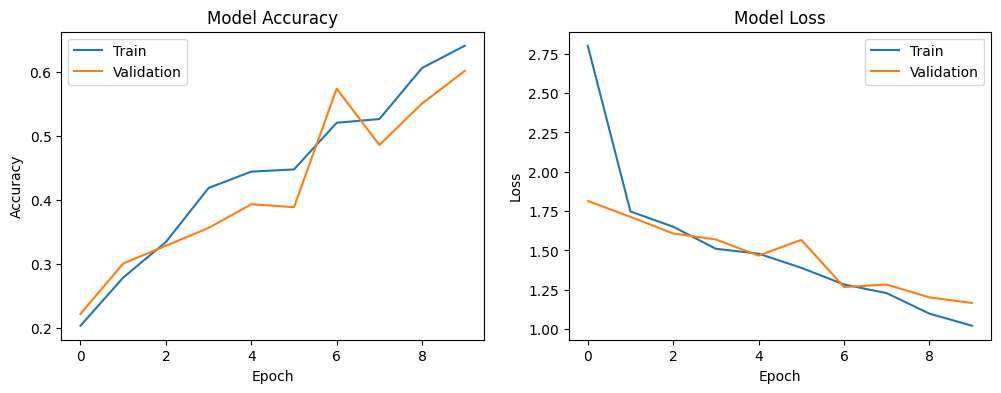

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


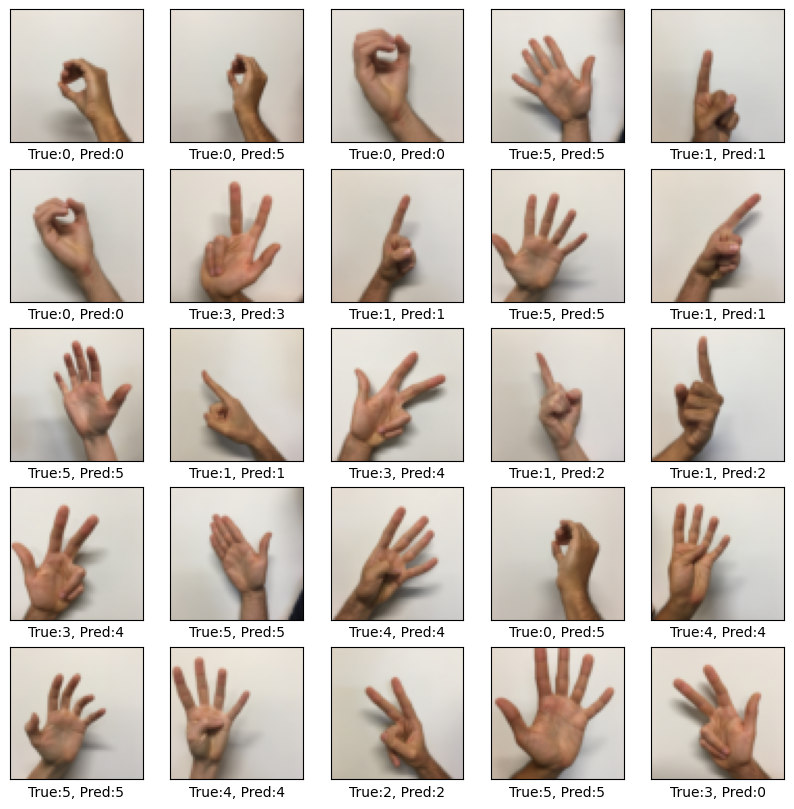

In [ ]:
# Install necessary libraries
!pip install tensorflow matplotlib h5py

# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import h5py
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

# Dataset paths
train_path = "/content/drive/MyDrive/Signs_Data_Training.h5"
test_path = "/content/drive/MyDrive/Signs_Data_Testing.h5"

# Load Training Data
with h5py.File(train_path, "r") as train_dataset:
    x_train = np.array(train_dataset["train_set_x"])
    y_train = np.array(train_dataset["train_set_y"])

# Load Testing Data
with h5py.File(test_path, "r") as test_dataset:
    x_test = np.array(test_dataset["test_set_x"])
    y_test = np.array(test_dataset["test_set_y"])

# Normalize image data
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encode labels (6 classes)
y_train = to_categorical(y_train, 6)
y_test = to_categorical(y_test, 6)

# Build the MLP Model
model = Sequential([
    Flatten(input_shape=(64, 64, 3)),   # signs dataset images usually 64x64x3
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

# Evaluate Model
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

# Plot Training Graphs
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

# Predictions
predictions = model.predict(x_test)

# Display Predictions
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[i])
    plt.xlabel(f"True:{np.argmax(y_test[i])}, Pred:{np.argmax(predictions[i])}")

plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
import h5py
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, regularizers

# Dataset paths
train_path = "/content/drive/MyDrive/Signs_Data_Training.h5"
test_path = "/content/drive/MyDrive/Signs_Data_Testing.h5"

# Load training data
with h5py.File(train_path, "r") as train_dataset:
    x_train = np.array(train_dataset["train_set_x"])
    y_train = np.array(train_dataset["train_set_y"])

# Load testing data
with h5py.File(test_path, "r") as test_dataset:
    x_test = np.array(test_dataset["test_set_x"])
    y_test = np.array(test_dataset["test_set_y"])

# Normalize images
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images (64x64x3 → 12288)
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

# One-hot encode labels (6 classes)
y_train = to_categorical(y_train, 6)
y_test = to_categorical(y_test, 6)

# Build MLP with L2 Regularization
def build_l2_model():
    model = models.Sequential([
        layers.Dense(
            128,
            activation='relu',
            input_shape=(x_train.shape[1],),
            kernel_regularizer=regularizers.l2(0.01)
        ),

        layers.Dense(
            64,
            activation='relu',
            kernel_regularizer=regularizers.l2(0.01)
        ),

        layers.Dense(6, activation='softmax')
    ])

    return model


model_l2 = build_l2_model()

# Compile model
model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model_l2.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

# Evaluate model
test_loss, test_acc = model_l2.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.1887 - loss: 5.3757 - val_accuracy: 0.1759 - val_loss: 3.8163
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.2697 - loss: 3.5057 - val_accuracy: 0.1898 - val_loss: 3.2735
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.2766 - loss: 3.1736 - val_accuracy: 0.2824 - val_loss: 2.8109
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.3403 - loss: 2.7821 - val_accuracy: 0.3056 - val_loss: 2.6628
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4282 - loss: 2.3485 - val_accuracy: 0.3611 - val_loss: 2.3723
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4792 - loss: 2.1856 - val_accuracy: 0.4583 - val_loss: 2.1242
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4792 - loss: 2.0515 - val_accuracy: 0.3102 - val_loss: 2.1978
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4850 - loss: 1.9702 - val_accuracy: 0.3796 - v

In [ ]:
import tensorflow as tf
import numpy as np
import h5py
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, regularizers

# Load dataset
train_path = "/content/drive/MyDrive/Signs_Data_Training.h5"
test_path = "/content/drive/MyDrive/Signs_Data_Testing.h5"

with h5py.File(train_path, "r") as train_dataset:
    x_train = np.array(train_dataset["train_set_x"])
    y_train = np.array(train_dataset["train_set_y"])

with h5py.File(test_path, "r") as test_dataset:
    x_test = np.array(test_dataset["test_set_x"])
    y_test = np.array(test_dataset["test_set_y"])

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten images
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

# One hot encoding
y_train = to_categorical(y_train, 6)
y_test = to_categorical(y_test, 6)

# Improved model
model = models.Sequential([
    layers.Dense(512, activation='relu',
                 kernel_regularizer=regularizers.l2(0.0001),
                 input_shape=(x_train.shape[1],)),

    layers.Dense(256, activation='relu'),

    layers.Dense(128, activation='relu'),

    layers.Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - accuracy: 0.1794 - loss: 4.3673 - val_accuracy: 0.1435 - val_loss: 2.5868
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - accuracy: 0.2303 - loss: 2.5171 - val_accuracy: 0.2454 - val_loss: 1.9874
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 178ms/step - accuracy: 0.3056 - loss: 1.7946 - val_accuracy: 0.2407 - val_loss: 1.8451
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - accuracy: 0.3611 - loss: 1.6860 - val_accuracy: 0.3981 - val_loss: 1.6226
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.4074 - loss: 1.6493 - val_accuracy: 0.4583 - val_loss: 1.5782
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.4792 - loss: 1.4377 - val_accuracy: 0.3704 - val_loss: 1.6308
Epoch 7/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - accuracy: 0.4988 - loss: 1.3549 - val_accuracy: 0.4306 - val_loss: 1.5596
Epoch 8/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step - accuracy: 0.5417 - loss: 1.2814 - val_accuracy: 0.

In [ ]:
import h5py
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_path = "/content/drive/MyDrive/Signs_Data_Training.h5"
test_path = "/content/drive/MyDrive/Signs_Data_Testing.h5"

with h5py.File(train_path, "r") as train_dataset:
    x_train = np.array(train_dataset["train_set_x"])
    y_train = np.array(train_dataset["train_set_y"])

with h5py.File(test_path, "r") as test_dataset:
    x_test = np.array(test_dataset["test_set_x"])
    y_test = np.array(test_dataset["test_set_y"])
# Normalize data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 🔹 Reshape to (samples, 64, 64, 3) for augmentation (corrected from 28,28,1)
x_train = x_train.reshape(-1, 64, 64, 3)
x_test = x_test.reshape(-1, 64, 64, 3)

# One-hot encode labels (corrected from 10 classes to 6)
y_train = to_categorical(y_train, 6)
y_test = to_categorical(y_test, 6)

# 🔹 Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False,
    vertical_flip=False
)

datagen.fit(x_train)

# 🔹 Build Model (with L2 regularization)
def build_l2_model():
    model = models.Sequential([
        layers.Flatten(input_shape=(64, 64, 3)), # Corrected input_shape
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(6, activation='softmax') # Corrected output classes from 16 to 6
    ])
    return model

model_l2 = build_l2_model()

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🔹 Train using augmented data
history = model_l2.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(x_test, y_test),
    steps_per_epoch=len(x_train) // 32
)

# 🔹 Evaluate model
test_loss, test_acc = model_l2.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.1737 - loss: 4.1132 - val_accuracy: 0.1750 - val_loss: 2.9851
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1562 - loss: 2.9702 - val_accuracy: 0.1750 - val_loss: 2.9682
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.2071 - loss: 2.8491 - val_accuracy: 0.1333 - val_loss: 2.7436
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0938 - loss: 2.7535 - val_accuracy: 0.1667 - val_loss: 2.7311
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.2366 - loss: 2.5784 - val_accuracy: 0.2583 - val_loss: 2.5133
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1562 - loss: 2.4977 - val_accuracy: 0.1833 - val_loss: 2.4852
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.2242 - loss: 2.3854 - val_accuracy: 0.3000 - val_loss: 2.2304
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3438 - loss: 2.2491 - val_accuracy: 0.3167 - val_l

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# Load the MNIST dataset
# The dataset loading and preprocessing steps are handled in previous cells,
# ensuring `x_train`, `y_train`, `x_test`, `y_test` are available.

# Build simple model (NO L2 regularization)
def build_model():
    model = models.Sequential([
        layers.Flatten(input_shape=(x_train.shape[1], x_train.shape[2], x_train.shape[3])), # Add Flatten layer
        layers.Dense(64, activation='relu'), # input_shape removed as Flatten handles it
        layers.Dense(64, activation='relu'),
        layers.Dense(6, activation='softmax') # Corrected output classes for Signs_Data
    ])
    return model

model = build_model()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🔹 Early Stopping
earlystop = EarlyStopping(
    monitor='val_accuracy',   # Monitor validation accuracy
    patience=3,               # Stop if no improvement after 3 epochs
    restore_best_weights=True # Restore best model weights
)

epochs = 20  # change this value and check
batch_size = 256   # change this value and check

# Train model with Early Stopping
history = model.fit(
    x_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    callbacks=[earlystop]
)

# Evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 202ms/step - accuracy: 0.1528 - loss: 4.8814 - val_accuracy: 0.1528 - val_loss: 2.4126
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.1725 - loss: 2.5157 - val_accuracy: 0.1713 - val_loss: 2.2333
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.1539 - loss: 2.3463 - val_accuracy: 0.1296 - val_loss: 2.0008
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.1713 - loss: 1.9229 - val_accuracy: 0.1528 - val_loss: 1.8839
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.1968 - loss: 1.8339 - val_accuracy: 0.1806 - val_loss: 1.8122
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.1944 - loss: 1.7589 - val_accuracy: 0.3287 - val_loss: 1.7171
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.2130 - loss: 1.7278 - val_accuracy: 0.2407 - val_loss: 1.7295
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.2326 - loss: 1.7282 - val_accuracy: 0.2731 - val_loss: 1.6723
Epoch 9/2

In [ ]:
import tensorflow as tf
import numpy as np
import h5py
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models

# --------------------------------------------------
# Function to load dataset
# --------------------------------------------------
def load_dataset(train_path, test_path):

    with h5py.File(train_path, "r") as train_dataset:
        X_train = np.array(train_dataset["train_set_x"])
        Y_train = np.array(train_dataset["train_set_y"])

    with h5py.File(test_path, "r") as test_dataset:
        X_test = np.array(test_dataset["test_set_x"])
        Y_test = np.array(test_dataset["test_set_y"])

    # Normalize
    X_train = X_train.astype("float32") / 255.0
    X_test = X_test.astype("float32") / 255.0

    # Flatten images (64*64*3 = 12288)
    X_train = X_train.reshape(X_train.shape[0], -1)
    X_test = X_test.reshape(X_test.shape[0], -1)

    # One-hot encode labels
    Y_train = to_categorical(Y_train, 6)
    Y_test = to_categorical(Y_test, 6)

    return X_train, Y_train, X_test, Y_test


# --------------------------------------------------
# Function to build MLP model
# --------------------------------------------------
def build_model():

    model = models.Sequential([

        layers.Dense(256, activation='relu', input_shape=(12288,)),
        layers.Dropout(0.3),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu'),

        layers.Dense(6, activation='softmax')

    ])

    return model


# --------------------------------------------------
# Function to train model
# --------------------------------------------------
def train_model(model, X_train, Y_train):

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train,
        Y_train,
        epochs=20,
        batch_size=64,
        validation_split=0.2
    )

    return history


# --------------------------------------------------
# Function to evaluate model
# --------------------------------------------------
def evaluate_model(model, X_test, Y_test):

    test_loss, test_acc = model.evaluate(X_test, Y_test)

    print("Test Accuracy:", test_acc)


# --------------------------------------------------
# MAIN PROGRAM
# --------------------------------------------------
train_path = "/content/drive/MyDrive/Signs_Data_Training.h5" # Corrected path
test_path = "/content/drive/MyDrive/Signs_Data_Testing.h5"   # Corrected path

X_train, Y_train, X_test, Y_test = load_dataset(train_path, test_path)

model = build_model()

train_model(model, X_train, Y_train)

evaluate_model(model, X_test, Y_test)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.1968 - loss: 4.3723 - val_accuracy: 0.2222 - val_loss: 1.8364
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.1586 - loss: 1.9507 - val_accuracy: 0.1528 - val_loss: 1.7886
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.1736 - loss: 1.7829 - val_accuracy: 0.1528 - val_loss: 1.7955
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.1516 - loss: 1.7912 - val_accuracy: 0.1806 - val_loss: 1.7927
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.1667 - loss: 1.7917 - val_accuracy: 0.1806 - val_loss: 1.7929
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.1667 - loss: 1.7917 - val_accuracy: 0.1296 - val_loss: 1.7931
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.1597 - loss: 1.7916 - val_accuracy: 0.1528 - val_loss: 1.7931
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.1725 - loss: 1.7916 - val_accuracy: 0.1296 - v

In [ ]:
noise_factor = 0.2
x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape)

# Keep pixel values between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)

# ===============================
# 🔹 Add Noise to OUTPUTS (Label Noise)
# Randomly flip 10% of labels
# ===============================
noise_ratio = 0.1
num_samples = int(noise_ratio * y_train.shape[0])

random_indices = np.random.choice(y_train.shape[0], num_samples, replace=False)

for idx in random_indices:
    # Generate random label within the correct range (0-5 for 6 classes)
    random_label = np.random.randint(0, 6)
    # One-hot encode for 6 classes
    y_train[idx] = tf.keras.utils.to_categorical(random_label, 6)

# ===============================
# Build Model (same as original)
# ===============================
def build_model():
    model = models.Sequential([
        layers.Flatten(input_shape=(x_train.shape[1], x_train.shape[2], x_train.shape[3])),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(6, activation='softmax') # Corrected output classes for Signs_Data
    ])
    return model

model = build_model()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model using noisy inputs and noisy labels
history = model.fit(
    x_train_noisy,
    y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2
)

# Evaluate on clean test data
test_loss, test_acc = model.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 0.1782 - loss: 3.8516 - val_accuracy: 0.1852 - val_loss: 4.7423
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.1609 - loss: 3.8810 - val_accuracy: 0.1806 - val_loss: 3.5063
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.1759 - loss: 3.0177 - val_accuracy: 0.1806 - val_loss: 2.0312
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.1968 - loss: 2.1058 - val_accuracy: 0.2130 - val_loss: 2.3895
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.1852 - loss: 2.2450 - val_accuracy: 0.2222 - val_loss: 1.9478
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.1979 - loss: 1.8610 - val_accuracy: 0.1898 - val_loss: 2.0727
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.1921 - loss: 1.9667 - val_accuracy: 0.2315 - val_loss: 1.8886
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.2870 - loss: 1.8362 - val_accuracy: 0.2176 - val_loss: 1.7649
Epoch 9/20

In [ ]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models

# Flatten x_train and x_test to 1D vectors for these MLP models
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

# ==================================
# 🔹 Model 1: Simple Dense
# ==================================
model1 = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(x_train.shape[1],)),
    layers.Dense(6, activation='softmax')
])

model1.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

model1.fit(x_train, y_train,
           epochs=5, batch_size=256, verbose=0)

# ==================================
# 🔹 Model 2: Medium Dense (NEW)
# ==================================
model2 = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(x_train.shape[1],)),
    layers.Dense(6, activation='softmax')
])

model2.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

model2.fit(x_train, y_train,
           epochs=5, batch_size=256, verbose=0)

# ==================================
# 🔹 Model 3: Deeper Dense
# ==================================
model3 = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(x_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(6, activation='softmax')
])

model3.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

model3.fit(x_train, y_train,
           epochs=5, batch_size=256, verbose=0)

# ==================================
# 🔹 Individual Model Accuracies
# ==================================
print("Model 1 Accuracy:", model1.evaluate(x_test, y_test, verbose=0)[1])
print("Model 2 Accuracy:", model2.evaluate(x_test, y_test, verbose=0)[1])
print("Model 3 Accuracy:", model3.evaluate(x_test, y_test, verbose=0)[1])

# ==================================
# 🔹 Ensemble (Soft Voting)
# ==================================

pred1 = model1.predict(x_test)
pred2 = model2.predict(x_test)
pred3 = model3.predict(x_test)

# Average predictions
ensemble_pred = (pred1 + pred2 + pred3) / 3

# Convert probabilities to class labels
ensemble_classes = np.argmax(ensemble_pred, axis=1)

# Compute ensemble accuracy
ensemble_accuracy = np.mean(ensemble_classes == np.argmax(y_test, axis=1)) # Compare with true labels after argmax

print("Ensemble Accuracy:", ensemble_accuracy)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model 1 Accuracy: 0.2083333283662796
Model 2 Accuracy: 0.1666666716337204
Model 3 Accuracy: 0.32499998807907104
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Ensemble Accuracy: 0.31666666666666665


In [ ]:
# Install libraries
!pip install tensorflow h5py

import numpy as np
import tensorflow as tf
import h5py
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models

# --------------------------------------------------
# Load Dataset
# --------------------------------------------------

def load_dataset(train_path, test_path):

    with h5py.File(train_path, "r") as train_dataset:
        X_train = np.array(train_dataset["train_set_x"])
        Y_train = np.array(train_dataset["train_set_y"])

    with h5py.File(test_path, "r") as test_dataset:
        X_test = np.array(test_dataset["test_set_x"])
        Y_test = np.array(test_dataset["test_set_y"])

    # Normalize
    X_train = X_train.astype("float32") / 255.0
    X_test = X_test.astype("float32") / 255.0

    # Flatten images
    X_train = X_train.reshape(X_train.shape[0], -1)
    X_test = X_test.reshape(X_test.shape[0], -1)

    # One hot encoding
    Y_train = to_categorical(Y_train, 6)
    Y_test = to_categorical(Y_test, 6)

    return X_train, Y_train, X_test, Y_test


# --------------------------------------------------
# Build MLP Model
# --------------------------------------------------

def build_model():

    model = models.Sequential([

        layers.Input(shape=(12288,)),

        layers.Dense(512, activation='relu'),
        layers.Dropout(0.4),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(128, activation='relu'),

        layers.Dense(6, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# --------------------------------------------------
# Train Model
# --------------------------------------------------

def train_model(model, X_train, Y_train):

    model.fit(
        X_train,
        Y_train,
        epochs=30,
        batch_size=32,
        validation_split=0.2,
        verbose=1
    )

    return model


# --------------------------------------------------
# Ensemble Prediction
# --------------------------------------------------

def ensemble_prediction(models, X_test, Y_test):

    preds = [model.predict(X_test) for model in models]

    ensemble_pred = np.mean(preds, axis=0)

    final_pred = np.argmax(ensemble_pred, axis=1)
    true_labels = np.argmax(Y_test, axis=1)

    accuracy = np.mean(final_pred == true_labels)

    print("Ensemble Accuracy:", accuracy)


# --------------------------------------------------
# MAIN PROGRAM
# --------------------------------------------------

train_path = "/content/drive/MyDrive/Signs_Data_Training.h5" # Corrected path
test_path = "/content/drive/MyDrive/Signs_Data_Testing.h5"

X_train, Y_train, X_test, Y_test = load_dataset(train_path, test_path)

# Train 3 models
model1 = train_model(build_model(), X_train, Y_train)
model2 = train_model(build_model(), X_train, Y_train)
model3 = train_model(build_model(), X_train, Y_train)

# Individual accuracy
print("Model 1 Accuracy:", model1.evaluate(X_test, Y_test)[1])
print("Model 2 Accuracy:", model2.evaluate(X_test, Y_test)[1])
print("Model 3 Accuracy:", model3.evaluate(X_test, Y_test)[1])

# Ensemble accuracy
ensemble_prediction([model1, model2, model3], X_test, Y_test)

Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.1667 - loss: 5.9090 - val_accuracy: 0.1528 - val_loss: 2.0438
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.1910 - loss: 2.0928 - val_accuracy: 0.1852 - val_loss: 1.7787
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.1609 - loss: 1.7982 - val_accuracy: 0.1296 - val_loss: 1.7920
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.1713 - loss: 1.7918 - val_accuracy: 0.1296 - val_loss: 1.7921
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.1759 - loss: 1.7919 - val_accuracy: 0.1296 - val_loss: 1.7925
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.1759 - loss: 1.7918 - val_accuracy: 0.1296 - val_loss: 1.7925
Epoch 7/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - accuracy: 0.1759 - loss: 1.7917 - val_accuracy: 0.1296 - val_loss: 1.7929
Epoch 8/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.1759 - loss: 1.7917 - val_accuracy: 0.1296 

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Ensemble Accuracy: 0.16666666666666666


In [ ]:
import tensorflow as tf
import numpy as np
import h5py
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Dataset paths
train_path = "/content/drive/MyDrive/Signs_Data_Training.h5"
test_path = "/content/drive/MyDrive/Signs_Data_Testing.h5"

# Load training data
with h5py.File(train_path, "r") as train_dataset:
    x_train = np.array(train_dataset["train_set_x"])
    y_train = np.array(train_dataset["train_set_y"])

# Load testing data
with h5py.File(test_path, "r") as test_dataset:
    x_test = np.array(test_dataset["test_set_x"])
    y_test = np.array(test_dataset["test_set_y"])

# Normalize images
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape images for CNN (64x64x3)
x_train = x_train.reshape(x_train.shape[0], 64, 64, 3)
x_test = x_test.reshape(x_test.shape[0], 64, 64, 3)

# One-hot encode labels (6 classes)
y_train = to_categorical(y_train, 6)
y_test = to_categorical(y_test, 6)

# Build an improved CNN model with Dropout
model_cnn_improved = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation='relu'), # Added more filters
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation='relu'), # Increased dense layer size
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax') # 6 output classes for Signs_Data
])

# Compile model with a learning rate scheduler
optimizer = optimizers.Adam(learning_rate=0.001)
model_cnn_improved.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Learning rate scheduler
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.2,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

# Train model
history_cnn_improved = model_cnn_improved.fit(
    x_train,
    y_train,
    epochs=30, # Increased epochs for better learning with scheduler
    validation_split=0.2,
    batch_size=32, # Using a common batch size
    callbacks=[reduce_lr]
)

# Evaluate model
test_loss_cnn_improved, test_acc_cnn_improved = model_cnn_improved.evaluate(x_test, y_test)

print(f"Improved CNN Test Accuracy: {test_acc_cnn_improved:.4f}")

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 328ms/step - accuracy: 0.1898 - loss: 1.8255 - val_accuracy: 0.2083 - val_loss: 1.7915 - learning_rate: 0.0010
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 254ms/step - accuracy: 0.2176 - loss: 1.7770 - val_accuracy: 0.1991 - val_loss: 1.7701 - learning_rate: 0.0010
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 326ms/step - accuracy: 0.3241 - loss: 1.6360 - val_accuracy: 0.4583 - val_loss: 1.4779 - learning_rate: 0.0010
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 243ms/step - accuracy: 0.4398 - loss: 1.3770 - val_accuracy: 0.5602 - val_loss: 1.1845 - learning_rate: 0.0010
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 244ms/step - accuracy: 0.5231 - loss: 1.1761 - val_accuracy: 0.5093 - val_loss: 1.2306 - learning_rate: 0.0010
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 336ms/step - accuracy: 0.5810 - loss: 1.1008 - val_accuracy: 0.6019 - val_loss: 1.0762 - learning_rate: 0.0010
Epoch 7/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 241ms/step - accuracy: 0.6817 - loss: 0.8779 - val_accu

### Understanding Lower Accuracy with L2 Regularization

L2 regularization works by adding a term to the loss function that is proportional to the sum of the squares of the model's weights. This penalty term pushes the weights towards smaller values, effectively simplifying the model.

**Why it can lead to lower accuracy (especially in your observed cases):**

1.  **Bias-Variance Trade-off:** Regularization introduces bias into the model to reduce variance. While it helps prevent the model from memorizing the training data (overfitting), too much regularization can cause the model to underfit, meaning it's too simple to capture the underlying patterns in the data effectively. This results in lower performance on both training and test sets.

2.  **Increased Training Loss/Accuracy:** The L2 penalty is added directly to the loss function. This means that the model is optimizing for a new objective: minimizing the original prediction error *plus* the penalty for large weights. Consequently, the raw prediction accuracy might be slightly lower compared to a non-regularized model if the model is already struggling to fit the data or if the regularization strength is too high.

3.  **Data Complexity and Model Capacity:** If the dataset is relatively small, or if the model's capacity (number of layers, neurons) is already limited, strong L2 regularization can further restrict its ability to learn. The `Signs_Data` dataset used in your notebook might be complex enough that applying strong L2 regularization too early or with inappropriate hyperparameters hinders the model's learning capacity.

4.  **Hyperparameter Tuning:** The `lambda` value (regularization strength) in `regularizers.l2(lambda)` is a crucial hyperparameter. If this value is too high, it will heavily penalize weights, forcing them to be very small, and potentially leading to underfitting and lower accuracy. In cell `Y4AEA88i3NvJ`, `kernel_regularizer=regularizers.l2(0.01)` was used, which might have been too aggressive, leading to a test accuracy of `0.4417`.

In your notebook, you observed lower accuracies with L2 regularization compared to some non-regularized or better-tuned models:

*   **Cell `Y4AEA88i3NvJ` (MLP with L2):** Achieved a test accuracy of `0.4417`.
*   **Cell `iEAM_N0q84c_` (Improved MLP with L2):** Achieved a test accuracy of `0.5583` (still lower than the final CNN model).

This suggests that the regularization strength (`0.01` in `Y4AEA88i3NvJ` and `0.0001` in `iEAM_N0q84c_`) might need further tuning, or that the MLP architecture itself, even with regularization, might not be as effective for this image classification task as a Convolutional Neural Network (CNN) like the one in `0324c182`, which achieved `0.9250` test accuracy.

### Improving Accuracy with Dropout

**What is Dropout?**

Dropout is a regularization technique where a certain percentage of neurons in a neural network layer are randomly 'dropped out' (i.e., temporarily ignored) during each training step. These neurons are chosen at random, and their weights are not updated, nor do they contribute to the forward or backward pass.

**How does it improve accuracy?**

1.  **Prevents Overfitting:** By randomly dropping neurons, the network cannot rely too heavily on any single neuron or specific set of neurons. This forces other neurons to pick up the slack and learn more robust features that are not dependent on the presence of any single neuron. This makes the model less sensitive to the specific weights of individual neurons, leading to better generalization.

2.  **Ensemble Effect:** Dropout can be thought of as training an ensemble of many different neural networks. Each time a different subset of neurons is dropped, a slightly different network is trained. At test time, all neurons are used, but their outputs are scaled down by the dropout rate. This averaging effect helps to combine the strengths of these 'sub-networks', often leading to improved performance.

3.  **Reduces Co-adaptation:** It prevents neurons from co-adapting too much. If neurons always appear together, they might develop specialized detection capabilities that work only in concert. Dropout breaks these co-dependencies, encouraging neurons to learn more generally useful features.

**Example in your notebook:**

In cell `D9ibB1THFplr`, you have already implemented dropout layers in your `build_model` function:

```python
def build_model():

    model = models.Sequential([

        layers.Dense(256, activation='relu', input_shape=(12288,)),
        layers.Dropout(0.3),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu'),

        layers.Dense(6, activation='softmax')

    ])
    return model
```

Here, `layers.Dropout(0.3)` means that 30% of the neurons in the preceding layer will be randomly set to zero during each training step. You can experiment with different dropout rates (e.g., 0.2 to 0.5) to find the optimal value for your specific model and dataset.

### Improving Accuracy with Data Augmentation

**What is Data Augmentation?**

Data augmentation is a technique used to artificially increase the size of a training dataset by creating modified versions of existing images. This is done by applying various random transformations to the images, such as rotations, shifts, zooms, flips, and changes in brightness.

**How does it improve accuracy?**

1.  **Prevents Overfitting:** By introducing variations in the training data, the model sees a wider range of examples during training. This makes the model more robust and less likely to overfit to the specific characteristics of the original training images. It learns to generalize better to unseen data.

2.  **Increases Dataset Size:** For tasks like image classification, getting a large, diverse dataset can be challenging. Data augmentation effectively expands the training set without requiring new data collection, which is particularly beneficial for smaller datasets.

3.  **Improves Generalization:** The model learns to recognize objects and patterns regardless of their orientation, position, or minor distortions. For example, if a model sees rotated versions of a sign during training, it's more likely to correctly classify a rotated sign in the test set.

4.  **Reduces Variance:** By making the model more robust to minor variations in input, data augmentation helps reduce the model's variance, leading to a more stable and accurate performance on new data.

**Example in your notebook:**

In cell `KjEl5j2CBoum`, you have implemented data augmentation using `ImageDataGenerator`:

```python
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False,
    vertical_flip=False
)

datagen.fit(x_train)

# ... (later in the cell)

history = model_l2.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(x_test, y_test),
    steps_per_epoch=len(x_train) // 32
)
```

This code applies various transformations like rotating images by 10 degrees, zooming in/out by 10%, shifting width and height by 10%, during training. Adjusting the parameters of `ImageDataGenerator` (e.g., `rotation_range`, `zoom_range`) can further fine-tune the augmentation strategy and potentially lead to better accuracy.